In [1]:
from datetime import datetime, timedelta
from functools import partial
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import talib

from samples.myStrategy import myStrategy as baseline_strategy

## Load Data

In [2]:
path = 'data/0050.TW.csv'
df = pd.read_csv(path)

adj_close = df['Adj Close']
date = df['Date']
date_set = set(date)
date_idx = pd.Index(date)

## Analysis

In [3]:
def set_title(beg_idx: int, end_idx: int, super: bool = False):
  day_num = end_idx - beg_idx + 1
  title = f'{date[beg_idx]} ~ {date[end_idx]}\n{day_num} trade days'
  if super:
    plt.suptitle(title)
  else:
    plt.title(title, fontsize=10)

In [4]:
def plot_rsi(
  close_price: np.ndarray,
  short_period: int, long_period: int
):
  fast = talib.RSI(close_price, timeperiod=short_period)
  slow = talib.RSI(close_price, timeperiod=long_period)

  plt.plot(fast, 'tab:orange')
  plt.plot(slow, 'tab:blue')

def plot_macd(
    close_price: np.ndarray,
    short_period: int, long_period: int, signal_period: int
):
  macd, signal, _ = talib.MACD(close_price, short_period, long_period, signal_period)

  plt.plot(macd, 'tab:orange')
  plt.plot(signal, 'tab:blue')

In [5]:
def plot_actions(close_price: np.ndarray, actions: list):
  buy = []
  sell = []

  for i, action in enumerate(actions):
    if action == 1:
      buy.append(close_price[i])
      sell.append(None)
    elif action == -1:
      buy.append(None)
      sell.append(close_price[i])
    else:
      buy.append(None)
      sell.append(None)

  plt.plot(buy, color='red', marker='^')
  plt.plot(sell, color='green', marker='v')

In [6]:
def get_nearest_workday_idx(date_str: str) -> int:
  ori_date = datetime.strptime(date_str, '%Y-%m-%d')
  date = ori_date

  delta_days = 1

  while date.strftime('%Y-%m-%d') not in date_set:
    date = ori_date + timedelta(days=delta_days)
    delta_days = -delta_days if delta_days > 0 else (-delta_days + 1)

  idx = date_idx.get_loc(date.strftime('%Y-%m-%d'))

  return idx

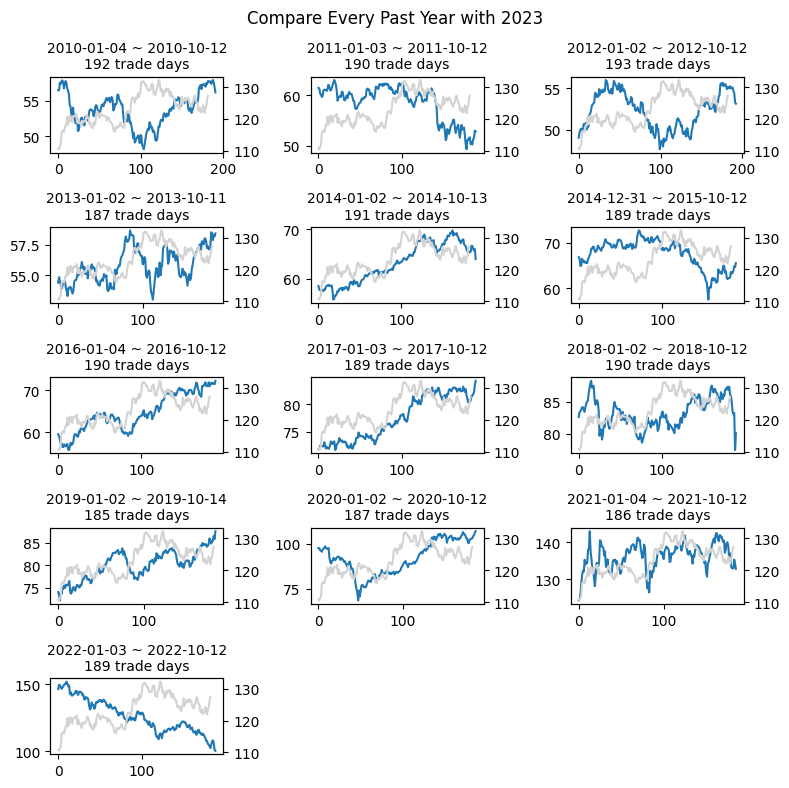

,rho
2017,0.734975
2014,0.723048
2016,0.564660
2019,0.433915
2021,0.390049
2020,0.312990
2013,0.254108
2018,0.108108
2015,-0.186388
2011,-0.232474


In [7]:
fig = plt.figure(figsize=(8, 8))

beg_idx = date_idx.get_loc('2023-01-03')
end_idx = date_idx.get_loc('2023-10-12')
close_price_2023 = adj_close[beg_idx:end_idx + 1].values

corr_list = pd.Series()

for y in range(2010, 2023):
  beg_idx = get_nearest_workday_idx(f'{y}-01-02')
  end_idx = get_nearest_workday_idx(f'{y}-10-12')
  close_price = adj_close[beg_idx:end_idx + 1].values

  min_len = min(close_price.shape[0], close_price_2023.shape[0])
  corr = np.corrcoef(close_price[:min_len], close_price_2023[:min_len])[0][1]
  corr_list[y] = corr

  plt.subplot(5, 3, y - 2009)
  set_title(beg_idx, end_idx)
  plt.plot(close_price)
  plt.twinx()
  plt.plot(close_price_2023, 'lightgray')

plt.suptitle(f'Compare Every Past Year with 2023')
plt.tight_layout()
plt.show()

rho = corr_list.sort_values(ascending=False)
pd.DataFrame({ 'rho': rho })

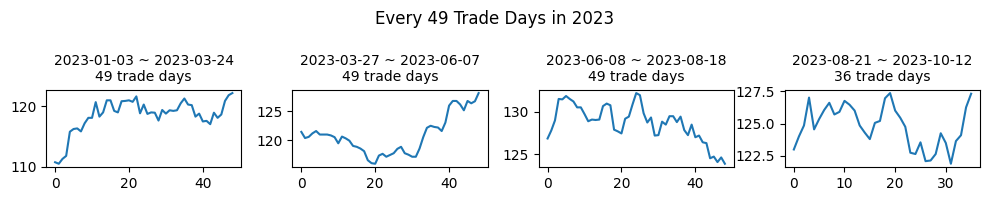

In [8]:
fig = plt.figure(figsize=(10, 2))

n = 49
interval = date[date.str.startswith('2023-')]
splits = [interval[i:i+n] for i in range(0, interval.shape[0], n)]
for i, split in enumerate(splits):
  beg_idx = split.index[0]
  end_idx = split.index[-1]
  close_price = adj_close[beg_idx:end_idx + 1].values

  plt.subplot(1, 4, i + 1)
  set_title(beg_idx, end_idx)
  plt.plot(close_price)

plt.suptitle(f'Every {n} Trade Days in 2023')
plt.tight_layout()
plt.show()

## Strategy
### Construction

In [9]:
def get_baseline_strategy_actions(prices: np.ndarray, beg_idx: int) -> list:
	actions = []

	for i in range(beg_idx, prices.shape[0]):
		action = baseline_strategy(prices[0:i], prices[i])
		actions.append(action)

	return actions

In [10]:
# optimal strategy
def get_best_actions(prices: np.ndarray, beg_idx: int) -> list:
  n = prices.shape[0] - beg_idx  # since we don't consider data before the target testing interval
  cash = np.zeros(n)
  stocks = np.zeros(n)
  action_logs = np.zeros((2, n))

  cash[0] = 1000
  stocks[0] = cash[0] / prices[beg_idx]
  action_logs[1][0] = 1

  for i in range(1, n):
    new_cash = stocks[i - 1] * prices[beg_idx + i]
    new_stock = cash[i - 1] / prices[beg_idx + i]

    if cash[i - 1] >= new_cash:
      cash[i] = cash[i - 1]
      action_logs[0][i] = 0
    else:
      cash[i] = new_cash
      action_logs[0][i] = -1

    if stocks[i - 1] >= new_stock:
      stocks[i] = stocks[i - 1]
      action_logs[1][i] = 0
    else:
      stocks[i] = new_stock
      action_logs[1][i] = 1

  idx = 0
  actions = []

  for i in range(n - 1, -1, -1):
    actions.append(action_logs[idx][i])
    if action_logs[idx][i] != 0:
      idx = 1 - idx

  return actions[::-1]

In [11]:
def get_rsi_strategy_actions(
  prices: np.ndarray, beg_idx: int,
  action_rise_above: int, action_fall_below: int,
  fast_ws: int, slow_ws: int,
  alpha: int, beta: int
) -> list:
  actions = []

  fast_rsi = talib.RSI(prices, timeperiod=fast_ws)
  slow_rsi = talib.RSI(prices, timeperiod=slow_ws)

  for i in range(beg_idx, prices.shape[0]):
    diff = fast_rsi[i] - slow_rsi[i]
    diff_prev = fast_rsi[i - 1] - slow_rsi[i - 1]

    if (beta < diff and diff < 0) or (diff > 0 and diff_prev <= 0):
      actions.append(action_rise_above)
    elif (0 < diff and diff < alpha) or (diff < 0 and diff_prev >= 0):
      actions.append(action_fall_below)
    else:
      actions.append(0)

  return actions

In [12]:
def get_macd_strategy_actions(
  prices: np.ndarray, beg_idx: int,
  action_rise_above: int, action_fall_below: int,
  fastperiod: int, slowperiod: int, signalperiod: int,
  alpha: int, beta: int
) -> list:
  actions = []

  _, _, hist = talib.MACD(prices, fastperiod, slowperiod, signalperiod)

  for i in range(beg_idx, prices.shape[0]):
    if (beta < hist[i] and hist[i] < 0) or (hist[i] > 0 and hist[i - 1] <= 0):
      actions.append(action_rise_above)
    elif (0 < hist[i] and hist[i] < alpha) or (hist[i] < 0 and hist[i - 1] >= 0):
      actions.append(action_fall_below)
    else:
      actions.append(0)

  return actions

In [13]:
def get_ma_strategy_actions(
    prices: np.ndarray, beg_idx: int,
    fast_ws: int, slow_ws: int,
    alpha: int, beta: int
) -> list:
  actions = []

  fast_ma = talib.EMA(prices, fast_ws)
  slow_ma = talib.EMA(prices, slow_ws)

  for i in range(beg_idx, prices.shape[0]):
    diff = fast_ma[i] - slow_ma[i]
    diff_prev = fast_ma[i - 1] - slow_ma[i - 1]

    if (beta < diff and diff < 0) or (diff > 0 and diff_prev <= 0):
      actions.append(1)
    elif (0 < diff and diff < alpha) or (diff < 0 and diff_prev >= 0):
      actions.append(-1)
    else:
      actions.append(0)

  return actions

In [14]:
def get_rsi_bound_strategy_actions(
  prices: np.ndarray, beg_idx: int,
  ws: int, alpha: int, beta: int
) -> list:
  actions = []

  rsi = talib.RSI(prices, timeperiod=ws)

  for i in range(beg_idx, prices.shape[0]):
    if rsi[i] > alpha:
      actions.append(-1)
    elif rsi[i] < beta:
      actions.append(1)
    else:
      actions.append(0)

  return actions

In [15]:
def get_hybrid_strategy_actions(
  prices: np.ndarray, beg_idx: int,
  rsi_ws: int, rsi_alpha: int, rsi_beta: int,
  fastperiod: int, slowperiod: int, signalperiod: int,
  macd_alpha: int, macd_beta: int
) -> list:
  actions = []

  rsi = talib.RSI(prices, rsi_ws)
  _, _, hist = talib.MACD(prices, fastperiod, slowperiod, signalperiod)

  for i in range(beg_idx, prices.shape[0]):
    if rsi[i] > rsi_alpha:
      actions.append(-1)
    elif rsi[i] < rsi_beta:
      actions.append(1)
    elif (macd_beta < hist[i] and hist[i] < 0) or (hist[i] > 0 and hist[i - 1] <= 0):
      actions.append(1)
    elif (0 < hist[i] and hist[i] < macd_alpha) or (hist[i] < 0 and hist[i - 1] >= 0):
      actions.append(-1)
    else:
      actions.append(0)

  return actions

### Fitting

In [16]:
def calculate_return_rate(prices: np.ndarray, actions: list) -> float:
	capital = 1000
	stock_holding = 0

	for i, action in enumerate(actions):
		curr_price = prices[i]
		if action == 1 and capital > 0:
			stock_holding = capital / curr_price
			capital = 0
		elif action == -1 and stock_holding > 0:
			capital = stock_holding * curr_price
			stock_holding = 0

	final = capital + stock_holding * curr_price
	return (final - 1000) / 1000

#### 1. Specify Fitting Interval

In [17]:
n = 49
fit_interval = date[date.str.startswith('2017-')]
history_beg = fit_interval.index[0] - n
fit_splits = [(i, i + n) for i in range(fit_interval.index[0], fit_interval.index[-1] + 1, n)]

#### 2. RSI Strategy

In [18]:
param_names_rsi = (
  'action_rise_above',
  'action_fall_below',
  'fast_ws',
  'slow_ws',
  'alpha',
  'beta'
)

best_params_rsi = [ None ] * 2

action_rise_above = 1
action_fall_below = -1

for dir in range(2):
  max_rr = 0

  for fast_ws in range(2, 21):
    for slow_ws in range(fast_ws + 1, 41):
      for alpha in [0.1, 0.2, 0.3]:
        for beta in [-0.1, -0.2, -0.3]:
          total_rr = 0

          for split in fit_splits:
            prices = adj_close[history_beg:split[1]].values
            trade_np_beg = split[0] - history_beg
            actions = get_rsi_strategy_actions(
              prices, trade_np_beg,
              action_rise_above, action_fall_below,
              fast_ws, slow_ws,
              alpha, beta
            )
            total_rr += calculate_return_rate(prices[trade_np_beg:], actions)

          if total_rr > max_rr:
            max_rr = total_rr
            best_params_rsi[dir] = (
              action_rise_above, action_fall_below,
              fast_ws, slow_ws,
              alpha, beta
            )

  print('[Original]' if dir == 0 else '\n[Inverse]')
  print(f'Maximized Total Return Rate: {max_rr * 100:.2f}%')
  print('Best Params:')
  for name, value in zip(param_names_rsi[2:], best_params_rsi[dir][2:]):
    print(f'- {name}: {value}')

  action_rise_above, action_fall_below = action_fall_below, action_rise_above

best_params_dict_rsi = [dict(zip(param_names_rsi, best_params_rsi[dir])) for dir in range(2)]

[Original]
Maximized Total Return Rate: 18.43%
Best Params:
- fast_ws: 19
- slow_ws: 20
- alpha: 0.2
- beta: -0.3

[Inverse]
Maximized Total Return Rate: 16.22%
Best Params:
- fast_ws: 12
- slow_ws: 13
- alpha: 0.2
- beta: -0.1


#### 3. MACD Strategy

In [19]:
param_names_macd = (
  'action_rise_above',
  'action_fall_below',
  'fastperiod',
  'slowperiod',
  'signalperiod',
  'alpha',
  'beta'
)

best_params_macd = [ None ] * 2

action_rise_above = 1
action_fall_below = -1

for dir in range(2):
  max_rr = 0

  for signalperiod in range(2, 21):
    for fastperiod in range(signalperiod + 1, 31):
      for slowperiod in range(fastperiod + 1, 41):
        for alpha in [0.1, 0.2, 0.3]:
          for beta in [-0.1, -0.2, -0.3]:
            total_rr = 0

            for split in fit_splits:
              prices = adj_close[history_beg:split[1]].values
              trade_np_beg = split[0] - history_beg
              actions = get_macd_strategy_actions(
                prices, trade_np_beg,
                action_rise_above, action_fall_below,
                fastperiod, slowperiod, signalperiod,
                alpha, beta
              )
              total_rr += calculate_return_rate(prices[trade_np_beg:], actions)

            if total_rr > max_rr:
              max_rr = total_rr
              best_params_macd[dir] = (
                action_rise_above, action_fall_below,
                fastperiod, slowperiod, signalperiod,
                alpha, beta
              )

  print('[Original]' if dir == 0 else '\n[Inverse]')
  print(f'Maximized Total Return Rate: {max_rr * 100:.2f}%')
  print('Best Params:')
  for name, value in zip(param_names_macd[2:], best_params_macd[dir][2:]):
    print(f'- {name}: {value}')

  action_rise_above, action_fall_below = action_fall_below, action_rise_above

best_params_dict_macd = [dict(zip(param_names_macd, best_params_macd[dir])) for dir in range(2)]

[Original]
Maximized Total Return Rate: 20.98%
Best Params:
- fastperiod: 8
- slowperiod: 37
- signalperiod: 7
- alpha: 0.1
- beta: -0.3

[Inverse]
Maximized Total Return Rate: 13.96%
Best Params:
- fastperiod: 5
- slowperiod: 11
- signalperiod: 3
- alpha: 0.2
- beta: -0.1


#### 4. MA Strategy

In [20]:
param_names_ma = (
  'fast_ws',
  'slow_ws',
  'alpha',
  'beta'
)

max_rr = 0
best_params_ma = None

for fast_ws in range(2, 21):
  for slow_ws in range(fast_ws + 1, 41):
    for alpha in [0.1, 0.2, 0.3]:
      for beta in [-0.1, -0.2, -0.3]:
        total_rr = 0

        for split in fit_splits:
          prices = adj_close[history_beg:split[1]].values
          trade_np_beg = split[0] - history_beg
          actions = get_ma_strategy_actions(
            prices, trade_np_beg,
            fast_ws, slow_ws,
            alpha, beta
          )
          total_rr += calculate_return_rate(prices[trade_np_beg:], actions)

        if total_rr > max_rr:
          max_rr = total_rr
          best_params_ma = (fast_ws, slow_ws, alpha, beta)

best_params_dict_ma = dict(zip(param_names_ma, best_params_ma))

print(f'Maximized Total Return Rate: {max_rr * 100:.2f}%')
print('Best Params:')
for name, value in best_params_dict_ma.items():
  print(f'- {name}: {value}')

Maximized Total Return Rate: 21.21%
Best Params:
- fast_ws: 3
- slow_ws: 13
- alpha: 0.1
- beta: -0.3


#### 5. RSI Bound Strategy

In [21]:
param_names_rsi_bound = (
  'ws',
  'alpha',
  'beta'
)

max_rr = 0
best_params_rsi_bound = None

for ws in range(2, 41):
  for alpha in range(55, 100, 5):
    for beta in range(5, 50, 5):
      total_rr = 0

      for split in fit_splits:
        prices = adj_close[history_beg:split[1]].values
        trade_np_beg = split[0] - history_beg
        actions = get_rsi_bound_strategy_actions(
          prices, trade_np_beg,
          ws, alpha, beta
        )
        total_rr += calculate_return_rate(prices[trade_np_beg:], actions)

      if total_rr > max_rr:
        max_rr = total_rr
        best_params_rsi_bound = (ws, alpha, beta)

best_params_dict_rsi_bound = dict(zip(param_names_rsi_bound, best_params_rsi_bound))

print(f'Maximized Total Return Rate: {max_rr * 100:.2f}%')
print('Best Params:')
for name, value in best_params_dict_rsi_bound.items():
  print(f'- {name}: {value}')

Maximized Total Return Rate: 17.69%
Best Params:
- ws: 5
- alpha: 90
- beta: 45


#### 6. Hybrid Strategy

In [22]:
param_names_hybrid = (
  'rsi_ws',
  'rsi_alpha',
  'rsi_beta',
  'fastperiod',
  'slowperiod',
  'signalperiod',
  'macd_alpha',
  'macd_beta'
)

max_rr = 0
best_params_hybrid = None

for ws in range(2, 41, 2):
  for rsi_alpha in range(70, 81, 2):
    for rsi_beta in range(30, 41, 2):
      for signalperiod in range(2, 21, 2):
        for fastperiod in range(signalperiod + 1, 31, 2):
          for slowperiod in range(fastperiod + 1, 41, 2):
            for macd_alpha in [0.1, 0.2, 0.3]:
              for macd_beta in [-0.1, -0.2, -0.3]:
                total_rr = 0

                for split in fit_splits:
                  prices = adj_close[history_beg:split[1]].values
                  trade_np_beg = split[0] - history_beg
                  actions = get_hybrid_strategy_actions(
                    prices, trade_np_beg,
                    ws, rsi_alpha, rsi_beta,
                    fastperiod, slowperiod, signalperiod,
                    macd_alpha, macd_beta
                  )
                  total_rr += calculate_return_rate(prices[trade_np_beg:], actions)

                if total_rr > max_rr:
                  max_rr = total_rr
                  best_params_hybrid = (
                    ws, rsi_alpha, rsi_beta,
                    fastperiod, slowperiod, signalperiod,
                    macd_alpha, macd_beta
                  )

best_params_dict_hybrid = dict(zip(param_names_hybrid, best_params_hybrid))

print(f'Maximized Total Return Rate: {max_rr * 100:.2f}%')
print('Best Params:')
for name, value in best_params_dict_hybrid.items():
  print(f'- {name}: {value}')

Maximized Total Return Rate: 22.47%
Best Params:
- rsi_ws: 10
- rsi_alpha: 78
- rsi_beta: 40
- fastperiod: 9
- slowperiod: 22
- signalperiod: 8
- macd_alpha: 0.1
- macd_beta: -0.1


### Testing

In [23]:
get_fitted_rsi_strategy_actions = partial(
  get_rsi_strategy_actions,
  **best_params_dict_rsi[0]
)
get_fitted_rsi_inv_strategy_actions = partial(
  get_rsi_strategy_actions,
  **best_params_dict_rsi[1]
)
get_fitted_macd_strategy_actions = partial(
  get_macd_strategy_actions,
  **best_params_dict_macd[0]
)
get_fitted_macd_inv_strategy_actions = partial(
  get_macd_strategy_actions,
  **best_params_dict_macd[1]
)
get_fitted_ma_strategy_actions = partial(
  get_ma_strategy_actions,
  **best_params_dict_ma
)
get_fitted_rsi_bound_strategy_actions = partial(
  get_rsi_bound_strategy_actions,
  **best_params_dict_rsi_bound
)
get_fitted_hybrid_strategy_actions = partial(
  get_hybrid_strategy_actions,
  **best_params_dict_hybrid
)

#### 2023-01-03 ~ 2023-10-12

In [24]:
n = 49
history_beg = date_idx.get_loc('2019-01-02')
test_interval = date[date.str.startswith('2023-')]
test_splits = [(i, i + n) for i in range(test_interval.index[0], test_interval.index[-1] + 1, n)]

In [25]:
strategies = {
  'Baseline': get_baseline_strategy_actions,
  'OPT': get_best_actions,
  'RSI': get_fitted_rsi_strategy_actions,
  'RSI_inv': get_fitted_rsi_inv_strategy_actions,
  'MACD': get_fitted_macd_strategy_actions,
  'MACD_inv': get_fitted_macd_inv_strategy_actions,
  'MA': get_fitted_ma_strategy_actions,
  'RSI_bound': get_fitted_rsi_bound_strategy_actions,
  'Hybrid': get_fitted_hybrid_strategy_actions,
}
strategy_num = len(strategies)

action_list = [[] for _ in range(strategy_num)]
rr_list = [[] for _ in range(strategy_num)]

for split in test_splits:
  prices = adj_close[history_beg:split[1]].values
  trade_np_beg = split[0] - history_beg
  for i, strategy in enumerate(strategies.values()):
    actions = strategy(prices, trade_np_beg)
    rr = calculate_return_rate(prices[trade_np_beg:], actions)

    action_list[i] += actions
    rr_list[i].append(rr)

In [26]:
res = pd.DataFrame({ name: rr_log for name, rr_log in zip(strategies.keys(), rr_list) })
res = res.transpose() * 100
res['Total'] = res.sum(axis=1)
res['Average'] = res.mean(axis=1)

with pd.option_context('display.float_format', '{:.2f}%'.format):
  display(res)

,0,1,2,3,Total,Average
Baseline,4.13%,6.31%,-2.85%,-0.99%,6.60%,2.64%
OPT,27.79%,17.42%,15.10%,16.54%,76.85%,30.74%
RSI,11.63%,6.92%,-0.78%,0.19%,17.97%,7.19%
RSI_inv,1.68%,-0.12%,-4.44%,-0.48%,-3.36%,-1.34%
MACD,10.11%,5.87%,-4.32%,2.37%,14.03%,5.61%
MACD_inv,11.17%,-2.02%,-1.56%,1.12%,8.71%,3.48%
MA,9.30%,6.40%,-2.15%,0.24%,13.79%,5.51%
RSI_bound,12.31%,5.14%,-4.55%,3.50%,16.40%,6.56%
Hybrid,9.84%,-3.02%,-3.16%,5.18%,8.85%,3.54%


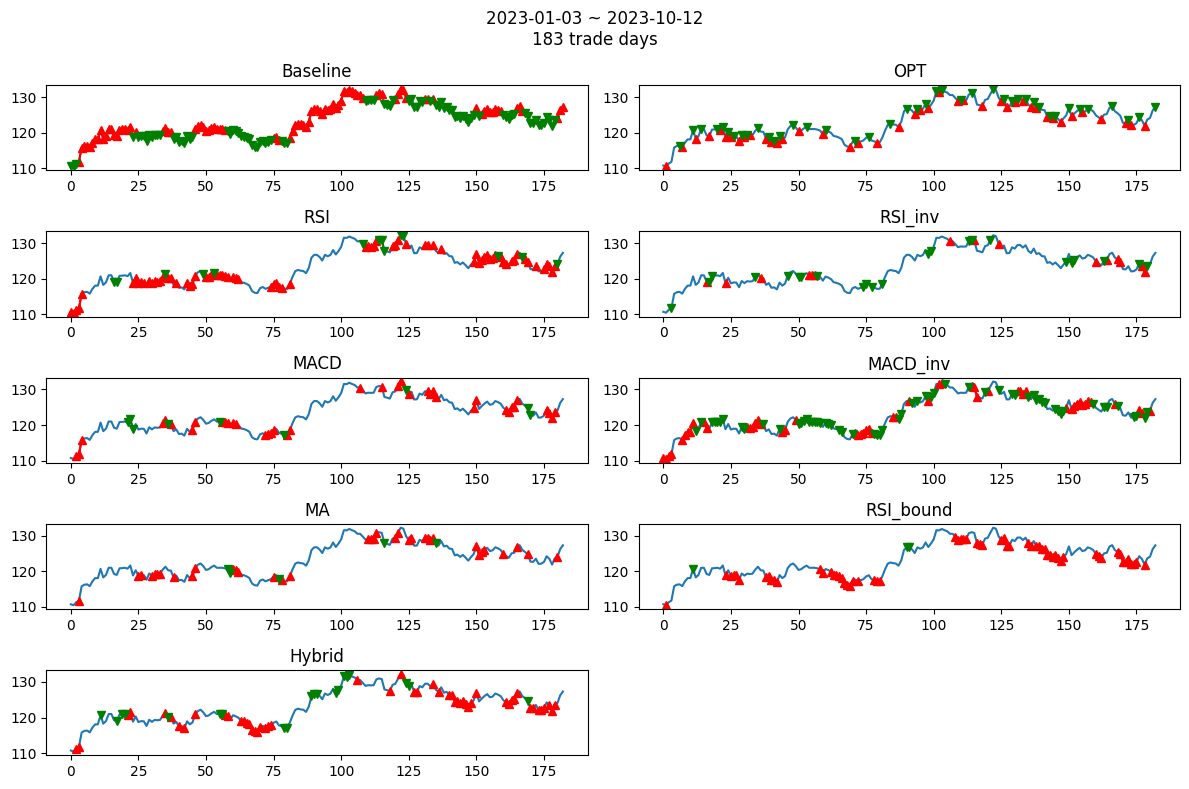

In [27]:
fig = plt.figure(figsize=(12, 8))

prices = adj_close[test_interval.index].values
for i, name in enumerate(strategies.keys()):
  plt.subplot(5, 2, i + 1)
  plt.title(name)
  plt.plot(prices)
  plot_actions(prices, action_list[i])

set_title(test_interval.index[0], test_interval.index[-1], True)
plt.tight_layout()
plt.show()

#### Nearly Every 10/16 ~ 12/22 period from 2010 to 2023

In [28]:
action_list = []
hy_rr_list = []
baseline_rr_list = []
best_rr_list = []

for y in range(2010, 2023):
  beg_idx = get_nearest_workday_idx(f'{y}-10-16')
  end_idx = get_nearest_workday_idx(f'{y}-12-22')
  history_beg = beg_idx - 49
  trade_np_beg = 49
  prices = adj_close[history_beg:end_idx + 1].values

  actions = get_fitted_hybrid_strategy_actions(prices, trade_np_beg)
  rr = calculate_return_rate(prices[trade_np_beg:], actions)
  action_list.append(actions)
  hy_rr_list.append(rr)

  actions = get_baseline_strategy_actions(prices, trade_np_beg)
  rr = calculate_return_rate(prices[trade_np_beg:], actions)
  baseline_rr_list.append(rr)

  actions = get_best_actions(prices, trade_np_beg)
  rr = calculate_return_rate(prices[trade_np_beg:], actions)
  best_rr_list.append(rr)

In [29]:
res = pd.DataFrame(
  {
    'Baseline': baseline_rr_list,
    'Hybrid': hy_rr_list,
    'OPT': best_rr_list,
  },
  index=range(2010, 2023)) * 100

with pd.option_context('display.float_format', '{:.2f}%'.format):
  display(res)

,Baseline,Hybrid,OPT
2010,1.17%,2.33%,17.95%
2011,-7.64%,-3.25%,28.63%
2012,1.36%,0.91%,16.85%
2013,-0.78%,5.39%,12.85%
2014,-1.05%,3.44%,22.46%
2015,-7.78%,-1.08%,17.66%
2016,0.28%,-1.88%,15.54%
2017,-0.83%,-2.01%,9.28%
2018,-4.01%,-4.98%,17.62%
2019,8.61%,7.68%,20.77%


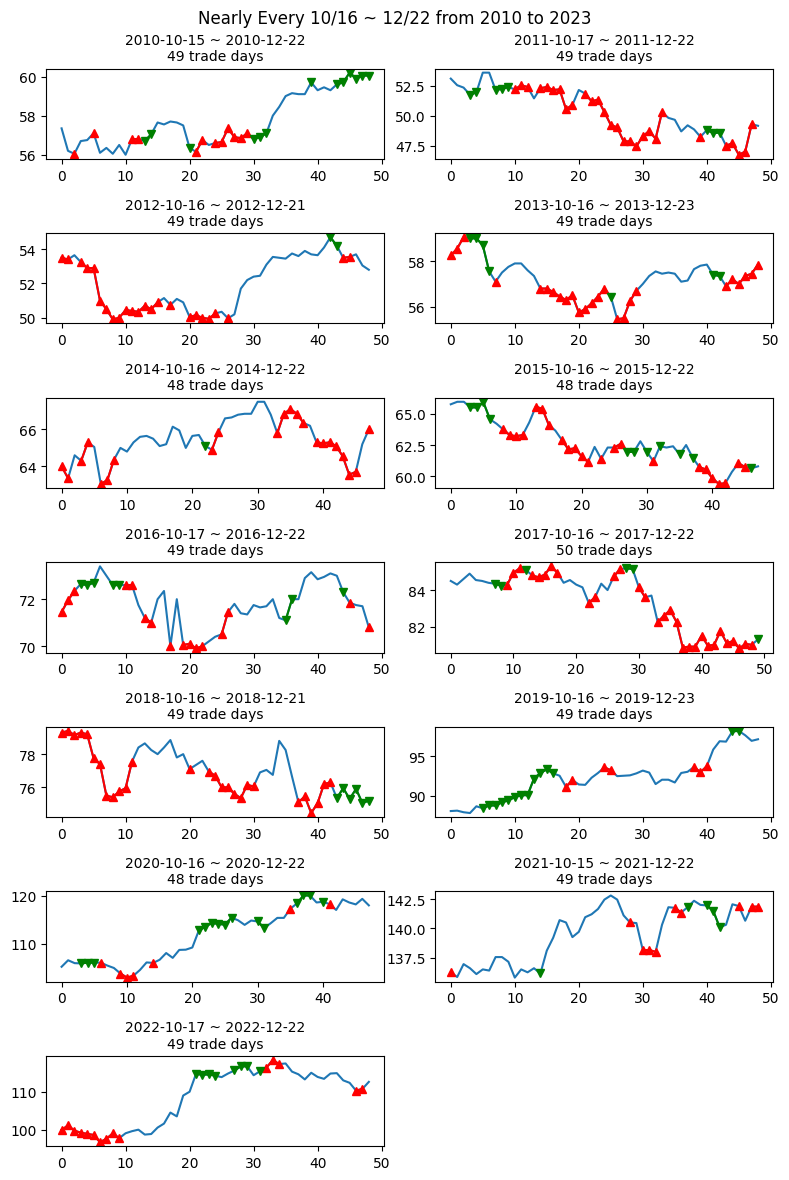

In [30]:
fig = plt.figure(figsize=(8, 12))

for y in range(2010, 2023):
  beg_idx = get_nearest_workday_idx(f'{y}-10-16')
  end_idx = get_nearest_workday_idx(f'{y}-12-22')
  prices = adj_close[beg_idx:end_idx + 1].values

  plt.subplot(7, 2, y - 2009)
  set_title(beg_idx, end_idx)
  plt.plot(prices)
  plot_actions(prices, action_list[y - 2010])

plt.suptitle('Nearly Every 10/16 ~ 12/22 from 2010 to 2023')
plt.tight_layout()
plt.show()